## Importing Required Libraries

In [24]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import imblearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

## Importing Dataset

In [25]:
data = pd.read_csv('../Dataset/loan_prediction.csv')
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


## Visualizing and Analysing the Data

Univariate Analysis

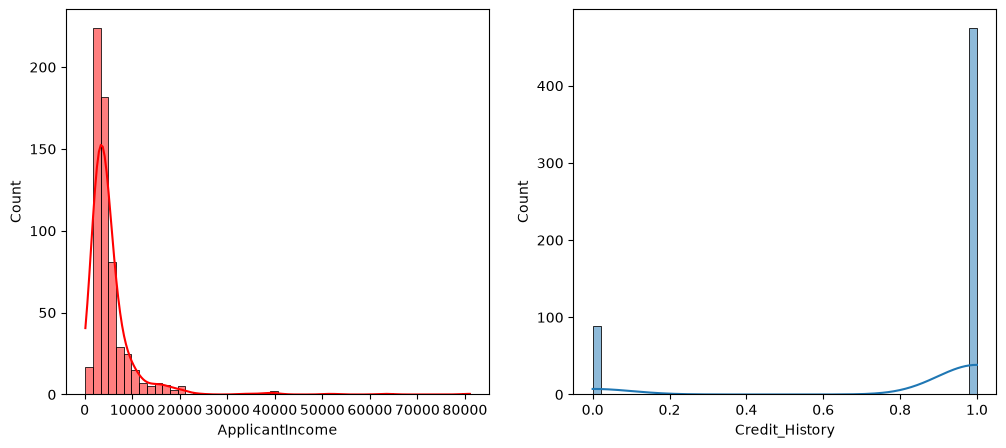

In [26]:
#plotting the distplot

plt.figure(figsize=(12,5))
plt.subplot(121)
sns.histplot(data['ApplicantIncome'],color='r',kde=True)
plt.subplot(122)
sns.histplot(data['Credit_History'],kde=True)
plt.show()

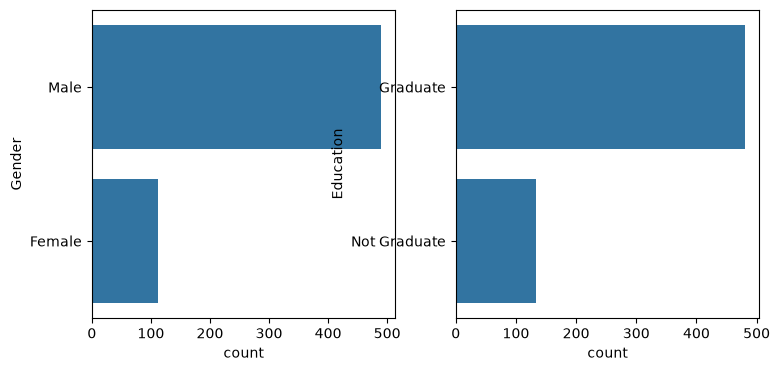

In [27]:
#plotting the countplot
plt.figure(figsize=(18,4))
plt.subplot(1,4,1)
sns.countplot(data['Gender'])
plt.subplot(1,4,2)
sns.countplot(data['Education'])
plt.show()

Bivariate Analysis

<Axes: xlabel='Property_Area', ylabel='count'>

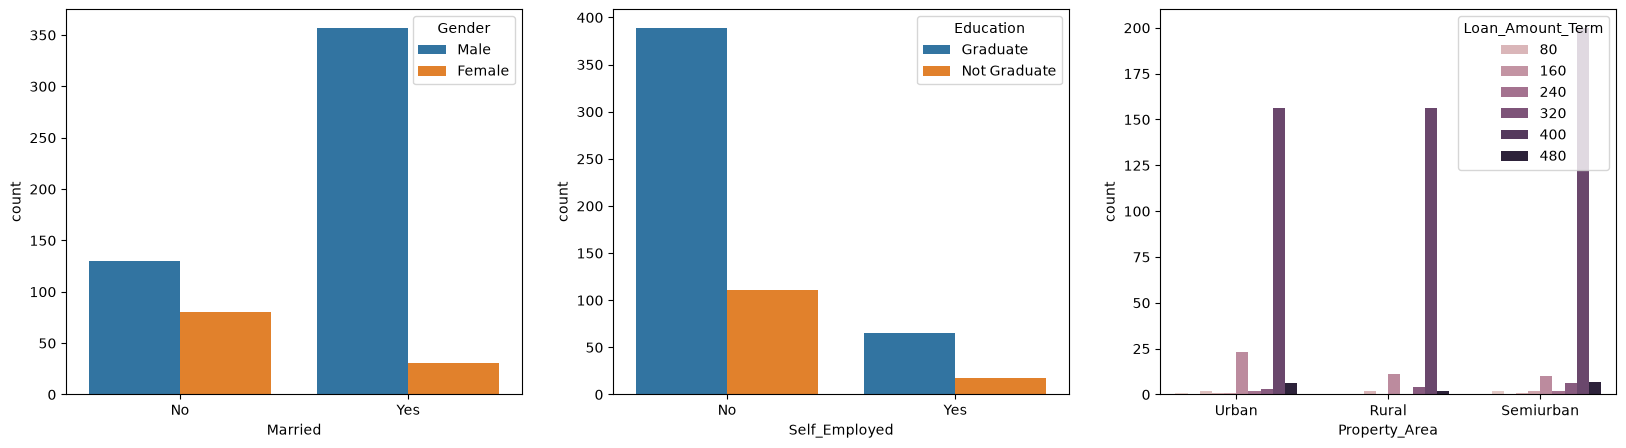

In [28]:
#visualising two columns against each other
plt.figure(figsize=(20,5))
plt.subplot(131)
sns.countplot(data=data, x='Married', hue='Gender')
plt.subplot(132)
sns.countplot(data=data, x='Self_Employed',hue='Education')
plt.subplot(133)
sns.countplot(data=data, x='Property_Area', hue='Loan_Amount_Term')

Multivariate Analysis

/home/naga/Documents/smartlender/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 45.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='Gender', ylabel='ApplicantIncome'>

/home/naga/Documents/smartlender/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 61.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/naga/Documents/smartlender/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


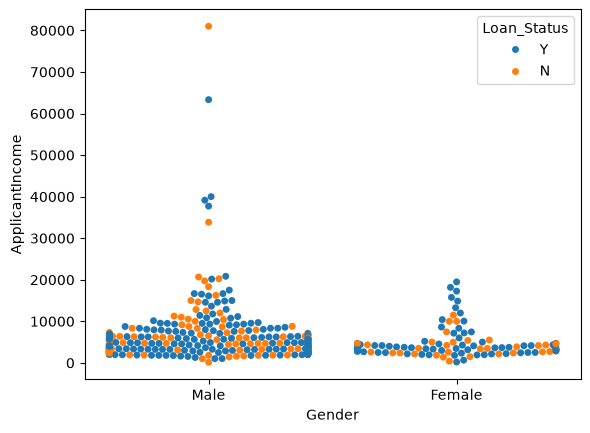

In [29]:
#Visualizing based on gender and income what would be the application status

# Pass the dataframe to 'data', and use strings for 'x', 'y', and 'hue'
sns.swarmplot(data=data, x='Gender', y='ApplicantIncome', hue='Loan_Status')

## Data Preprocessing

Handling Categorical Values

In [30]:
data['Gender'] = data['Gender'].map({'Female':1,'Male':0})
data['Property_Area'] = data['Property_Area'].map({'Urban':2,'Semiurban':1,'Rural':0})
data['Married'] = data['Married'].map({'Yes':1,'No':0})
data['Education'] = data['Education'].map({'Graduate':1,'Not Graudate':0})
data['Loan_Status'] = data['Loan_Status'].map({'Y':1,'N':0})
data['Self_Employed']= data['Self_Employed'].map({'Yes':1,'No':0})

data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0,1.0,0.0,5849,0.0,NaN,360.0,1.0,2,1
1,LP001003,0.0,1.0,1,1.0,0.0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,0.0,1.0,0,1.0,1.0,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,0.0,1.0,0,NaN,0.0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,0.0,0.0,0,1.0,0.0,6000,0.0,141.0,360.0,1.0,2,1


Handling Missing Values

In [31]:
print("Before Handling Missing Values")
print(data.isnull().sum())
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])

data['Dependents'] = data['Dependents'].str.replace('+','')
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].mode()[0])
data['Education'] = data['Education'].fillna(data['Education'].mode()[0])
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0])
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])
print("After Handling Missing Values")
print(data.isnull().sum())


Before Handling Missing Values
Loan_ID                0
Gender                13
Married                3
Dependents            15
Education            134
Self_Employed         32
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            22
Loan_Amount_Term      14
Credit_History        50
Property_Area          0
Loan_Status            0
dtype: int64
After Handling Missing Values
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [32]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    float64
 2   Married            614 non-null    float64
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    float64
 5   Self_Employed      614 non-null    float64
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    int64  
dtypes: float64(8), int64(3), str(2)
memory usage: 62.5 KB


Changing Data Types of each column to int

In [33]:
data['Gender'] = data['Gender'].astype('int')
data['Married'] = data['Married'].astype('int')
data['Dependents'] = data['Dependents'].astype('int')
data['CoapplicantIncome'] = data['CoapplicantIncome'].astype('int')
data['Self_Employed'] = data['Self_Employed'].astype('int')
data['LoanAmount'] = data['LoanAmount'].astype('int')
data['Education'] = data['Education'].astype('int')
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].astype('int')
data['Credit_History'] = data['Credit_History'].astype('int')

In [34]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Loan_ID            614 non-null    str  
 1   Gender             614 non-null    int64
 2   Married            614 non-null    int64
 3   Dependents         614 non-null    int64
 4   Education          614 non-null    int64
 5   Self_Employed      614 non-null    int64
 6   ApplicantIncome    614 non-null    int64
 7   CoapplicantIncome  614 non-null    int64
 8   LoanAmount         614 non-null    int64
 9   Loan_Amount_Term   614 non-null    int64
 10  Credit_History     614 non-null    int64
 11  Property_Area      614 non-null    int64
 12  Loan_Status        614 non-null    int64
dtypes: int64(12), str(1)
memory usage: 62.5 KB


## Model Buildling

In [35]:
#Splitting Data to Training and Testing
X = data.drop(['Loan_ID','Loan_Status'],axis=1)
Y = data['Loan_Status']
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

Decision Tree Model

In [36]:
def decisionTree(X_train,X_test,Y_train,Y_test):
    model = DecisionTreeClassifier()
    model.fit(X_train,Y_train)
    Y_train_pred = model.predict(X_train)
    print("Training_Accuracy:",accuracy_score(Y_train_pred,Y_train))
    Y_test_pred = model.predict(X_test)
    print("Testing_Accuarcy:",accuracy_score(Y_test_pred,Y_test))

decisionTree(X_train,X_test,Y_train,Y_test)
    

Training_Accuracy: 1.0
Testing_Accuarcy: 0.7886178861788617


Random Forest Model

In [37]:
def RandomForest(X_train,X_test,Y_train,Y_test):
    model = RandomForestClassifier()
    model.fit(X_train,Y_train)
    Y_train_pred = model.predict(X_train)
    print("Training_Accuracy:",accuracy_score(Y_train_pred,Y_train))
    Y_test_pred = model.predict(X_test)
    print("Testing_Accuarcy:",accuracy_score(Y_test_pred,Y_test))

RandomForest(X_train,X_test,Y_train,Y_test)
    

Training_Accuracy: 1.0
Testing_Accuarcy: 0.8455284552845529


KNeighborsClassifier

In [38]:
def KNN(X_train,X_test,Y_train,Y_test):
    model = KNeighborsClassifier()
    model.fit(X_train,Y_train)
    Y_train_pred = model.predict(X_train)
    print("Training_Accuracy:",accuracy_score(Y_train_pred,Y_train))
    Y_test_pred = model.predict(X_test)
    print("Testing_Accuarcy:",accuracy_score(Y_test_pred,Y_test))

KNN(X_train,X_test,Y_train,Y_test)

Training_Accuracy: 0.714867617107943
Testing_Accuarcy: 0.6504065040650406


Gradient Boost Model

In [40]:
def gradientBoost(X_train,X_test,Y_train,Y_test):
    model = GradientBoostingClassifier()
    model.fit(X_train,Y_train)
    Y_train_pred = model.predict(X_train)
    print("Training_Accuracy:",accuracy_score(Y_train_pred,Y_train))
    Y_test_pred = model.predict(X_test)
    print("Testing_Accuarcy:",accuracy_score(Y_test_pred,Y_test))

gradientBoost(X_train,X_test,Y_train,Y_test)

Training_Accuracy: 0.8940936863543788
Testing_Accuarcy: 0.7967479674796748


XGB Model

In [41]:
def XGB(X_train,X_test,Y_train,Y_test):
    model = XGBClassifier()
    model.fit(X_train,Y_train)
    Y_train_pred = model.predict(X_train)
    print("Training_Accuracy:",accuracy_score(Y_train_pred,Y_train))
    Y_test_pred = model.predict(X_test)
    print("Testing_Accuarcy:",accuracy_score(Y_test_pred,Y_test))

XGB(X_train,X_test,Y_train,Y_test)

Training_Accuracy: 1.0
Testing_Accuarcy: 0.7967479674796748


Evaluating Performance and Saving the Model

In [42]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_dist = {
    'n_estimators': [50, 100, 150, 200, 250, 300],  # Number of trees
    'max_depth': [3, 4, 5, 6, 7, 8],                # How deep the trees go
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],   # Step size shrinkage
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],         # Fraction of rows used per tree
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]   # Fraction of columns used per tree
}


random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,               # Number of random combinations to try
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',      # We want to maximize accuracy
    random_state=42,         # For reproducibility
    n_jobs=-1                # Use all computer processors to make it run faster!
)

print("Running Randomized Search... this might take a minute or two.")
random_search.fit(X, Y)

print("\nBest Accuracy Found:", random_search.best_score_)
print("Best Settings (Hyperparameters):", random_search.best_params_)

best_xgb_model = random_search.best_estimator_

model_filename = 'smartlender_tuned_xgboost.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_xgb_model, file)
print(f"\nSuccess! Tuned model saved as '{model_filename}'")

columns_filename = 'model_columns.pkl'
with open(columns_filename, 'wb') as file:
    pickle.dump(list(X.columns), file)
print(f"Success! Column names saved as '{columns_filename}'")

Running Randomized Search... this might take a minute or two.


/home/naga/Documents/smartlender/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [11:37:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/naga/Documents/smartlender/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [11:37:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/naga/Documents/smartlender/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [11:37:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/naga/Documents/smartlender/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [11:37:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not


Best Accuracy Found: 0.8111022257763562
Best Settings (Hyperparameters): {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

Success! Tuned model saved as 'smartlender_tuned_xgboost.pkl'
Success! Column names saved as 'model_columns.pkl'
